# Fine-Tuning Embeddings με InfoNCE Loss

Στο προηγούμενο notebook είδαμε πώς τα **προ-εκπαιδευμένα μοντέλα** (όπως το `bert-base-uncased` και το `all-MiniLM-L6-v2`) παράγουν σημασιολογικές ενσωματώσεις (semantic embeddings) για το πρόβλημα της αναζήτησης. Αυτά τα μοντέλα είναι γενικά — εκπαιδεύτηκαν σε τεράστιες ποσότητες κειμένου από το διαδίκτυο.

Επίσης είδαμε πως στα πειράματά μας με τα δεδομένα του NFCorpus, το `all-MiniLM-L6-v2` είχε σημαντικά καλύτερη επίδοση σε σχέση με το `bert-base-uncased`, παρόλο που έχουν την ίδια αρχιτεκτονική.

* Πώς δημιουργούμε ένα μοντέλο που παράγει καλές σημασιολογικές ενσωματώσεις;
* Πώς μπορούμε να το **βελτιώσουμε** για ένα συγκεκριμένο σύνολο δεδομένων;

Σε αυτό το notebook θα απαντήσουμε αυτές τις ερωτήσεις. Θα δούμε πως μπορούμε να βελτιώσουμε ένα μοντέλο για συγκεκριμένα δεδομένα, εκπαιδεύοντάς το με την απώλεια **InfoNCE loss**, γνωστή και ως **Contrastive Loss**.

<img src="https://drive.google.com/uc?id=197J0BuwnpmkTGyW_45qSeA-F6TudhNMK" alt="SciFact: Baseline vs InfoNCE Fine-tuning" width="600" height="auto">

```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```

## Η κεντρική ιδέα

Η εκπαίδευση απαιτεί ερωτήματα ${Q_i}$, και για κάθε ερώτημα, έγγραφα που είναι σχετικά (μεγάλη ομοιότητα), και μη σχετικά (μικρή ομοιότητα). Χρησιμοποιώντας δεδομένα αυτής της μορφής, εκπαιδεύουμε το μοντέλο να παράγει ενσωματώσεις για κάθε ερώτημα και κάθε κείμενο, ώστε:
- Ένα **ερώτημα** (query) πρέπει να έχει **υψηλή ομοιότητα** με τα **σχετικά έγγραφα** (positives)
- Και **χαμηλή ομοιότητα** με τα **μη σχετικά έγγραφα** (negatives)

```python
Query: "What causes Alzheimer's?"
  ↑ υψηλή cosine similarity
Positive: "Alzheimer's disease is caused by..."
  ↓ χαμηλή cosine similarity  
Negatives: "The recipe for chocolate cake...", "Stock market trends..."
```

## Τι θα κάνουμε

1. Φορτώνουμε το dataset **SciFact** από το BEIR benchmark (επιστημονικά γεγονότα + βιοϊατρικά άρθρα)
2. Υπολογίζουμε μετρικές αξιολόγησης (NDCG@10, Recall@10) με το προ-εκπαιδευμένο μοντέλο
3. Εκπαιδεύουμε το μοντέλο με **InfoNCE loss**
4. Συγκρίνουμε τα αποτελέσματα


## Εγκατάσταση βιβλιοθηκών

In [1]:
!pip install -q beir sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 15.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import random
from transformers import AutoTokenizer, AutoModel
from beir.datasets.data_loader import GenericDataLoader
from beir import util
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


## Φόρτωση Dataset: SciFact

Το **SciFact** είναι ένα σύνολο δεδομένων για επαλήθευση επιστημονικών ισχυρισμών:
- **Queries**: Ισχυρισμοί (claims) όπως *"Α πρωτεΐνη αναστέλλει την απόπτωση"*
- **Corpus**: ~5.000 περιλήψεις βιοϊατρικών άρθρων
- **Qrels**: Ποιο άρθρο υποστηρίζει κάθε ισχυρισμό

Προσοχή: τα δεδομένα δεν περιέχουν αρνητικά παραδείγματα. Το λεξικό Qrels περιέχει μόνο θετικά παραδείγματα, δηλαδή άρθρα που είναι σχετικά (μεγάλη ομοιότητα) με το κάθε ερώτημα. Η InfoNCE όμως, απαιτεί θετικά και αρνητικά παραδείγματα. Θα δούμε πως το αντιμετοπίζουμε αυτό το πρόβλημα.

Τα δεδομένα είναι χωρισμένα σε δεδομένα εκπαίδευσης (training data) και εκτίμησης (testing data) — ιδανικό για εκπαίδευση και αξιολόγηση.

In [4]:
# Κατεβάζουμε το SciFact dataset
url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip"
data_path = util.download_and_unzip(url, "datasets")
print(f"Dataset path: {data_path}")

Dataset path: datasets/scifact


In [5]:
# Φορτώνουμε train split (για εκπαίδευση)
corpus, train_queries, train_qrels = GenericDataLoader(data_folder=data_path).load(split="train")

# Φορτώνουμε test split (για αξιολόγηση)
_, test_queries, test_qrels = GenericDataLoader(data_folder=data_path).load(split="test")

print(f"Corpus: {len(corpus):,} έγγραφα")
print(f"Train queries: {len(train_queries):,}")
print(f"Test queries: {len(test_queries):,}")

  0%|          | 0/5183 [00:00<?, ?it/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Corpus: 5,183 έγγραφα
Train queries: 809
Test queries: 300


### Τα δεδομένα

Κοιτάμε τα δεδομένα -- για κάθε ερώτημα, η μέθοδος (και η απώλεια InfoNCE) απαιτεί θετικά και αρνητικά παραδείγματα.

In [6]:
# Ας δούμε ένα παράδειγμα
example_qid = list(train_queries.keys())[0]
print("Query:", train_queries[example_qid])
print()

# Θετικό παράδειγμα (relevant)
relevant_doc_id = list(train_qrels[example_qid].keys())[0]
doc = corpus[relevant_doc_id]
print("Σχετικό έγγραφο (τίτλος):", doc['title'])
print("Σχετικό έγγραφο (κείμενο):", doc['text'][:300], "...")
print()


Query: 0-dimensional biomaterials lack inductive properties.

Σχετικό έγγραφο (τίτλος): New opportunities: the use of nanotechnologies to manipulate and track stem cells.
Σχετικό έγγραφο (κείμενο): Nanotechnologies are emerging platforms that could be useful in measuring, understanding, and manipulating stem cells. Examples include magnetic nanoparticles and quantum dots for stem cell labeling and in vivo tracking; nanoparticles, carbon nanotubes, and polyplexes for the intracellular delivery  ...



### Αρνητικά Παραδείγματα

Τα δεδομένα μας δεν έχουν συγκεκριμένα αρνητικά παραδείγματα για κάθε ερώτημα. Το αντιμετωπίζουμε αυτό το πρόβλημα χρησιμοποιώντας τυχαία έγγραφα που δεν είναι στην λίστα των σχετικών εγγράφων, για αρνητικά παραδείγματα.

Θα χρησιμοποιήσουμε ακριβώς αυτήν την ιδέα για την εκπαίδευση.

Προσοχή: θα μπορούσαμε να χρησιμοποιήσουμε άλλες μεθόδους να βρούμε συγκεκριμένα αρνητικά παραδείγματα.

In [7]:
# Αρνητικό παράδειγμα (irrelevant)
all_doc_ids = set(corpus.keys())
relevant_doc_ids = set(train_qrels[example_qid].keys())
negative_doc_ids = list(all_doc_ids - relevant_doc_ids)
negative_doc_id = random.choice(negative_doc_ids)
neg_doc = corpus[negative_doc_id]
print("Άσχετο έγγραφο (τίτλος):", neg_doc['title'])
print("Άσχετο έγγραφο (κείμενο):", neg_doc['text'][:300], "...")

Άσχετο έγγραφο (τίτλος): Intestinal microbiota metabolism of L-carnitine, a nutrient in red meat, promotes atherosclerosis
Άσχετο έγγραφο (κείμενο): Intestinal microbiota metabolism of choline and phosphatidylcholine produces trimethylamine (TMA), which is further metabolized to a proatherogenic species, trimethylamine-N-oxide (TMAO). We demonstrate here that metabolism by intestinal microbiota of dietary L-carnitine, a trimethylamine abundant i ...


## Φόρτωση Μοντέλου

Χρησιμοποιούμε δύο μοντέλα που έχουμε δει και στο προηγούμενο Notebook.

* BERT: `bert-base-uncased` (~110 εκατομμύρια παραμέτρους)
- 12 layers transformer
- Παράγει embeddings διάστασης 768
- Προ-εκπαιδευμένο για MLM και segment-prediction, αλλά όχι για σημασιολογική ενσωμάτωση


* MINILM: `sentence-transformers/all-MiniLM-L6-v2` (~23 εκατομμύρια παραμέτρους)
- 6 layers transformer (πολύ πιο μικρό από BERT-base που έχει 12)
- Παράγει embeddings διάστασης 384
- Προ-εκπαιδευμένο για σημασιολογική ενσωμάτωση σε γενικά κείμενα

**Προσοχή**: Για να μετατρέψουμε τα token embeddings σε ένα μοναδικό embedding ανά πρόταση, χρησιμοποιούμε **mean pooling**: παίρνουμε τον μέσο όρο όλων των token embeddings (αγνοώντας τα padding tokens). Θα βρείτε τον κώδικα που το υλοποιεί αυτό στα επόμενα cells.

Στο [προηγούμενο Notebook όπου υπολογίζαμε ενσωματώσεις](https://colab.research.google.com/drive/19zJiRPA4IqZH9oF34Fc77W_JoBv0ONMv?usp=sharing) όλα αυτά μας τα έκανε αυτόματα η εντολή `model = SentenceTransformer('bert-base-uncased')` της Hugging Face. Επειδή εκπαιδεύουμε το μοντέλο, πρέπει να χρησιμοποιήσουμε την εντολή `model = AutoModel.from_pretrained(MODEL_NAME)` και να υπολογίσουμε μόνοι μας την τελική ενσωμάτωση που προκύπτει από τον μέσο όρο των τελικών tokens.

In [ ]:
# Τα διαθέσιμα sentence-transformers μοντέλα πρέπει να υπάρχουν στο Huggingface hub.

#MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME = "bert-base-uncased"  # Προσοχή! Όχι sentence-transformers/bert-base-uncased

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)

print(f"Μοντέλο: {MODEL_NAME}")
print(f"Παράμετροι: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Μοντέλο: bert-base-uncased
Παράμετροι: 109,482,240


### Mean Pooling & Normalization

Ορίζουμε δύο εντολές:

* ``mean_pool``: υπολογίζει τον μέσο όρο των token embeddings, αγνοώντας τα padding tokens.
* ``encode``: μετατρέπει λίστα κειμένων σε κανονικοποιημένες ενσωματώσεις (normalized embeddings).

In [ ]:
def mean_pool(token_embeddings, attention_mask):
    """Mean pooling: μέσος όρος των token embeddings, αγνοώντας τα padding tokens."""
    # Επεκτείνουμε το attention_mask ώστε να έχει το ίδιο shape με τα embeddings
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    # Αθροίζουμε μόνο τα μη-padding tokens και διαιρούμε με τον αριθμό τους
    return (token_embeddings * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


def encode(texts, batch_size=64):
    """Μετατρέπει λίστα κειμένων σε normalized embeddings."""
    all_embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            encoded = tokenizer(
                batch, padding=True, truncation=True, max_length=256, return_tensors="pt"
            ).to(device)
            output = model(**encoded)
            embs = mean_pool(output.last_hidden_state, encoded["attention_mask"])
            embs = F.normalize(embs, dim=-1)  # L2 normalization για cosine similarity
            all_embeddings.append(embs.cpu())
    return torch.cat(all_embeddings)

## Αξιολόγηση: NDCG@10 και Recall@10

Χρησιμοποιούμε δύο μετρικές αξιολόγησης για Information Retrieval:

**Recall@10**: Τι ποσοστό των σχετικών εγγράφων βρίσκεται στα top-10 αποτελέσματα;

**NDCG@10** (Normalized Discounted Cumulative Gain): Όπως το Recall, αλλά δίνει μεγαλύτερη βαρύτητα σε έγγραφα που εμφανίζονται πιο ψηλά στη λίστα. Ένα σχετικό έγγραφο στη θέση 1 είναι καλύτερο από στη θέση 10.

$$\text{NDCG@k} = \frac{\text{DCG@k}}{\text{IDCG@k}}, \quad \text{DCG@k} = \sum_{i=1}^{k} \frac{\text{rel}_i}{\log_2(i+1)}$$

In [ ]:
def evaluate(queries, qrels, k=10):
    """
    Αξιολογεί το μοντέλο σε ένα σύνολο queries.
    Επιστρέφει NDCG@k και Recall@k.
    """
    doc_ids = list(corpus.keys())
    doc_texts = [corpus[d]["title"] + " " + corpus[d]["text"] for d in doc_ids]
    print("Encoding corpus...")
    doc_embs = encode(doc_texts)

    ndcgs, recalls = [], []

    query_ids = [qid for qid in queries if qid in qrels]
    query_texts = [queries[qid] for qid in query_ids]
    print("Encoding queries...")
    query_embs = encode(query_texts)

    k_eff = min(k, len(doc_ids))

    for i, qid in enumerate(query_ids):
        relevant = {d for d, s in qrels[qid].items() if s > 0}
        if not relevant:
            continue

        scores = query_embs[i] @ doc_embs.T
        top_k_idx = scores.topk(k_eff).indices.tolist()
        retrieved = [doc_ids[j] for j in top_k_idx]

        hits = len(set(retrieved) & relevant)
        recalls.append(hits / len(relevant))

        rels = [1 if d in relevant else 0 for d in retrieved]
        dcg = sum(r / np.log2(rank + 2) for rank, r in enumerate(rels))

        num_rel = min(len(relevant), k_eff)
        idcg = sum(1 / np.log2(rank + 2) for rank in range(num_rel))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    mean_ndcg = float(np.mean(ndcgs)) if ndcgs else 0.0
    mean_recall = float(np.mean(recalls)) if recalls else 0.0

    return mean_ndcg, mean_recall

### Baseline: Αξιολόγηση χωρίς fine-tuning

In [ ]:
print("=== BASELINE (χωρίς fine-tuning) ===")
ndcg_before, recall_before = evaluate(test_queries, test_qrels, k=10)
print(f"NDCG@10  : {ndcg_before:.4f}")
print(f"Recall@10: {recall_before:.4f}")

=== BASELINE (χωρίς fine-tuning) ===
Encoding corpus...
Encoding queries...
NDCG@10  : 0.1670
Recall@10: 0.2567


## InfoNCE Loss

Η **InfoNCE loss** (Information Noise-Contrastive Estimation) είναι η βάση για τη σύγχρονη εκπαίδευση μοντέλων ενσωματώσεων. Επιτέλους θα δούμε πως αντιμετοπίζουμε το πρόβλημα που αναφέραμε: το σύνολο δεδομένων μας παρέχει μόνο θετικά παραδείγματα (σχετικά κείμενα) για κάθε ερώτημα (query), ενώ η μέθοδος εκπαίδευσης απαιτεί και αρνητικά (μη σχετικά) παραδείγματα.

### Η ιδέα με in-batch negatives

Για batch μεγέθους $B$, έχουμε $B$ ζεύγη (query, positive_doc). Αυτό το batch είναι επιλεγμένο τυχαία. Η απλή ιδέα των in-batch negatives: για κάθε ερώτημα $Q_i$, τα κείμενα $D_j$ για $j \not= i$ τα θεωρούμε ως μη σχετικά κείμενα.

### Συνάρτηση απώλειας

Για κάθε ερώτημα $Q_i$, η κανονικοποιημένη ενσωμάτωση είναι το διάνυσμα $\mathbf{q}_i$. Για κάθε κείμενο $D_i$, η κανονικοποιημένη ενσωμάτωση είναι το διάνυσμα $\mathbf{d}_i$.


Δημιουργούμε έναν **πίνακα ομοιότητας** $B \times B$:

$$S_{ij} = \frac{\mathbf{q}_i \cdot \mathbf{d}_j}{\tau}$$

όπου $\tau$ (temperature) είναι παράμετρος της εκπαίδευσης.

- Η **διαγώνιος** ($S_{ii}$): query $i$ με το δικό του positive doc → θέλουμε **υψηλή** τιμή
- Τα **off-diagonal** ($S_{ij}, i \neq j$): query $i$ με doc άλλου query → θέλουμε **χαμηλή** τιμή

Αυτό είναι ακριβώς **cross-entropy** με labels = `[0, 1, 2, ..., B-1]`!

```
         doc_0  doc_1  doc_2  ...  (πίνακας B×B)
query_0 [HIGH,  low,   low,  ...]
query_1 [low,   HIGH,  low,  ...]
query_2 [low,   low,   HIGH, ...]
```

Κάθε γραμμή είναι μια κατανομή πιθανότητας — θέλουμε η μέγιστη τιμή να είναι στη διαγώνιο.

In [ ]:
def infonce_loss(query_embs, doc_embs, temperature=0.07):
    """
    InfoNCE loss με in-batch negatives.

    query_embs: (B, D) - embeddings των queries
    doc_embs:   (B, D) - embeddings των positive εγγράφων

    Για κάθε query i, το positive είναι το doc_embs[i],
    και negatives είναι όλα τα άλλα doc_embs[j] με j != i.
    """
    # Normalization (για cosine similarity)
    query_embs = F.normalize(query_embs, dim=-1)
    doc_embs = F.normalize(doc_embs, dim=-1)

    # Πίνακας ομοιότητας: (B, B)
    # logits[i][j] = similarity(query_i, doc_j) / temperature
    logits = (query_embs @ doc_embs.T) / temperature

    # Labels: κάθε query i πρέπει να ταιριάζει με doc i (διαγώνιος)
    labels = torch.arange(len(query_embs), device=query_embs.device)

    # Cross-entropy loss (ισοδύναμη με την InfoNCE)
    return F.cross_entropy(logits, labels)

### Contrastive Loss και InfoNCE

Ας δούμε πώς μοιάζει ο πίνακας ομοιότητας πριν και μετά την εκπαίδευση.

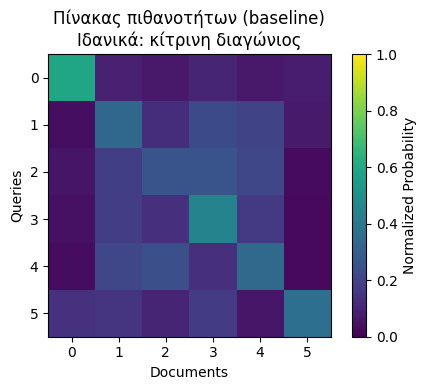

InfoNCE loss (baseline): 0.9761


In [ ]:
import matplotlib.pyplot as plt

# Παίρνουμε 6 ζεύγη (query, positive doc) για επίδειξη
demo_pairs = []
for qid in list(train_queries.keys())[:6]:
    if qid in train_qrels:
        pos_doc_id = list(train_qrels[qid].keys())[0]
        query_text = train_queries[qid]
        doc_text = corpus[pos_doc_id]["title"] + " " + corpus[pos_doc_id]["text"]
        demo_pairs.append((query_text, doc_text))

demo_queries = [p[0] for p in demo_pairs]
demo_docs = [p[1] for p in demo_pairs]

q_embs = encode(demo_queries)
d_embs = encode(demo_docs)

# Calculate logits and then softmax probabilities row-wise for plotting
logits = (F.normalize(q_embs, dim=-1) @ F.normalize(d_embs, dim=-1).T) / TEMPERATURE
sim_matrix_probs = F.softmax(logits, dim=1).numpy()

plt.figure(figsize=(5, 4))
plt.imshow(sim_matrix_probs, cmap='viridis', vmin=0, vmax=1) # Probabilities are between 0 and 1
plt.colorbar(label='Normalized Probability')
plt.title('Πίνακας πιθανοτήτων (baseline)\nΙδανικά: κίτρινη διαγώνιος')
plt.xlabel('Documents')
plt.ylabel('Queries')
plt.tight_layout()
plt.show()
print(f"InfoNCE loss (baseline): {infonce_loss(q_embs.to(device), d_embs.to(device)):.4f}")

## Προετοιμασία Δεδομένων Εκπαίδευσης

Από τα **train qrels** εξάγουμε ζεύγη `(query, positive_doc)`. Για κάθε query, κρατάμε ένα σχετικό έγγραφο.

In [ ]:
# Δημιουργία λίστας (query_text, doc_text) ζευγών
train_pairs = []
for qid, rels in train_qrels.items():
    query_text = train_queries[qid]
    for doc_id, score in rels.items():
        if score > 0:  # σχετικό έγγραφο
            doc_text = corpus[doc_id]["title"] + " " + corpus[doc_id]["text"]
            train_pairs.append((query_text, doc_text))

print(f"Ζεύγη εκπαίδευσης: {len(train_pairs)}")
print()
print("Παράδειγμα:")
print("  Query:", train_pairs[0][0])
print("  Doc:  ", train_pairs[0][1][:150], "...")

Ζεύγη εκπαίδευσης: 919

Παράδειγμα:
  Query: 0-dimensional biomaterials lack inductive properties.
  Doc:   New opportunities: the use of nanotechnologies to manipulate and track stem cells. Nanotechnologies are emerging platforms that could be useful in mea ...


## Fine-Tuning με InfoNCE

Ο βρόχος εκπαίδευσης είναι απλός:
1. Πάρε ένα batch από ζεύγη (query, doc)
2. Encode τα queries και τα docs
3. Υπολόγισε την InfoNCE loss
4. Backpropagation + optimizer step

Η InfoNCE χρησιμοποιεί **in-batch negatives**: κάθε doc στο batch γίνεται αυτόματα negative για τα άλλα queries. Όσο μεγαλύτερο το batch, τόσο περισσότερα negatives — και πιο δύσκολο (και χρήσιμο) το training signal.

In [ ]:
# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 2e-5
EPOCHS = 5
TEMPERATURE = 0.07

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Ανακατεύουμε τα ζεύγη
random.shuffle(train_pairs)

loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []

    with tqdm(range(0, len(train_pairs), BATCH_SIZE), desc=f"Epoch {epoch+1}/{EPOCHS}") as pbar:
        for start in pbar:
            batch = train_pairs[start : start + BATCH_SIZE]
            if len(batch) < 2:  # χρειαζόμαστε τουλάχιστον 2 ζεύγη για negatives
                continue

            queries_batch = [p[0] for p in batch]
            docs_batch = [p[1] for p in batch]

            # Tokenize
            q_enc = tokenizer(queries_batch, padding=True, truncation=True,
                              max_length=64, return_tensors="pt").to(device)
            d_enc = tokenizer(docs_batch, padding=True, truncation=True,
                              max_length=256, return_tensors="pt").to(device)

            # Forward pass
            q_out = model(**q_enc)
            d_out = model(**d_enc)

            # Mean pooling
            q_embs = mean_pool(q_out.last_hidden_state, q_enc["attention_mask"])
            d_embs = mean_pool(d_out.last_hidden_state, d_enc["attention_mask"])

            # InfoNCE loss
            loss = infonce_loss(q_embs, d_embs, temperature=TEMPERATURE)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}: μέση loss = {avg_loss:.4f}")

print("\nΕκπαίδευση ολοκληρώθηκε!")

Epoch 1/5:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1: μέση loss = 1.1867


Epoch 2/5:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 2: μέση loss = 0.3682


Epoch 3/5:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 3: μέση loss = 0.1557


Epoch 4/5:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 4: μέση loss = 0.1037


Epoch 5/5:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 5: μέση loss = 0.0850

Εκπαίδευση ολοκληρώθηκε!


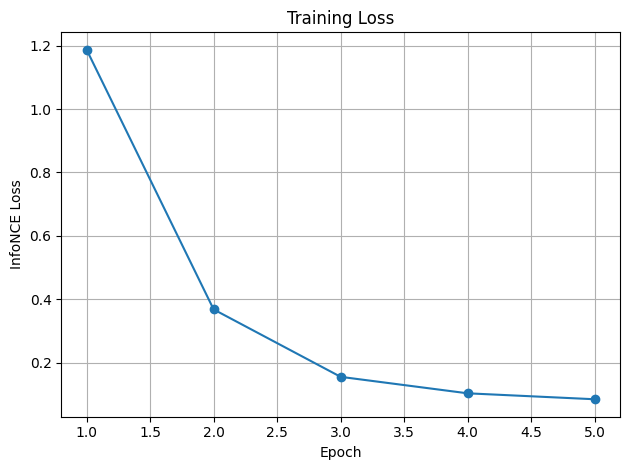

In [ ]:
# Οπτικοποίηση της loss κατά την εκπαίδευση
plt.plot(range(1, EPOCHS+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## Αξιολόγηση μετά το Fine-Tuning

In [ ]:
print("=== ΜΕΤΑ ΤΟ FINE-TUNING ===")
ndcg_after, recall_after = evaluate(test_queries, test_qrels, k=10)
print(f"NDCG@10  : {ndcg_after:.4f}")
print(f"Recall@10: {recall_after:.4f}")

=== ΜΕΤΑ ΤΟ FINE-TUNING ===
Encoding corpus...
Encoding queries...
NDCG@10  : 0.6226
Recall@10: 0.7709


## Σύγκριση Αποτελεσμάτων

In [ ]:
print("=" * 45)
print(f"{'Μετρική':<15} {'Baseline':>10} {'Fine-tuned':>12} {'Αλλαγή':>8}")
print("=" * 45)
print(f"{'NDCG@10':<15} {ndcg_before:>10.4f} {ndcg_after:>12.4f} {ndcg_after - ndcg_before:>+8.4f}")
print(f"{'Recall@10':<15} {recall_before:>10.4f} {recall_after:>12.4f} {recall_after - recall_before:>+8.4f}")
print("=" * 45)

Μετρική           Baseline   Fine-tuned   Αλλαγή
NDCG@10             0.1670       0.6226  +0.4556
Recall@10           0.2567       0.7709  +0.5142


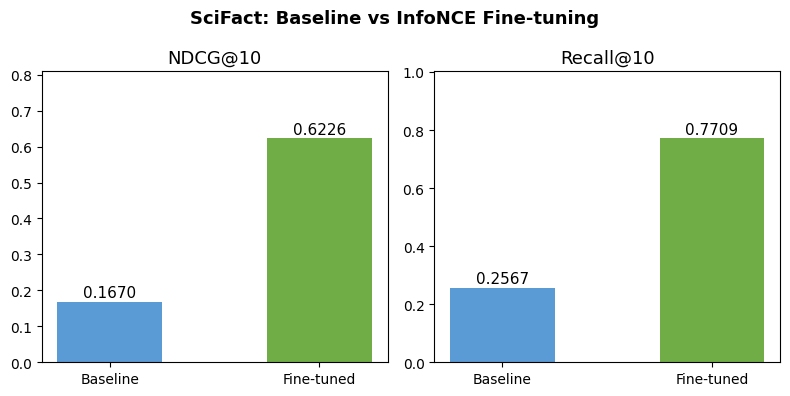

In [ ]:
# Οπτικοποίηση
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (metric, before, after) in zip(axes, [
    ("NDCG@10",   ndcg_before,   ndcg_after),
    ("Recall@10", recall_before, recall_after),
]):
    bars = ax.bar(["Baseline", "Fine-tuned"], [before, after],
                  color=["#5B9BD5", "#70AD47"], width=0.5)
    ax.set_ylim(0, max(before, after) * 1.3)
    ax.set_title(metric, fontsize=13)
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha='center', va='bottom', fontsize=11)

fig.suptitle("SciFact: Baseline vs InfoNCE Fine-tuning", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Επίδειξη του βελτιωμένου πίνακα ομοιότητας

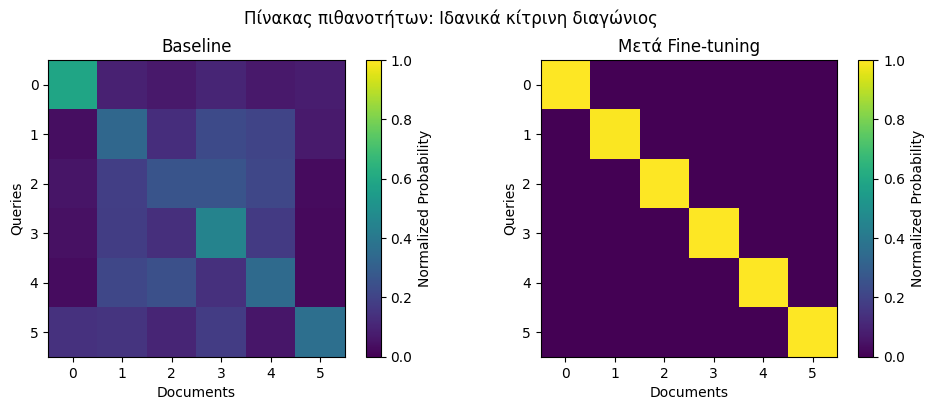

InfoNCE loss (baseline):     0.0759
InfoNCE loss (fine-tuned):   0.0018


In [ ]:
# Ίδια 6 ζεύγη όπως πριν — δείχνουμε πώς άλλαξε ο πίνακας
q_embs_after = encode(demo_queries)
d_embs_after = encode(demo_docs)

# Calculate logits and then softmax probabilities for the fine-tuned model
logits_after = (F.normalize(q_embs_after, dim=-1) @ F.normalize(d_embs_after, dim=-1).T) / TEMPERATURE
sim_matrix_probs_after = F.softmax(logits_after, dim=1).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, sim, title in zip(axes, [sim_matrix_probs, sim_matrix_probs_after], ["Baseline", "Μετά Fine-tuning"]):
    im = ax.imshow(sim, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Documents")
    ax.set_ylabel("Queries")
    plt.colorbar(im, ax=ax, label='Normalized Probability')

fig.suptitle('Πίνακας πιθανοτήτων: Ιδανικά κίτρινη διαγώνιος', fontsize=12)
plt.tight_layout()
plt.show()

loss_before_val = infonce_loss(q_embs.to(device), d_embs.to(device))
loss_after_val  = infonce_loss(q_embs_after.to(device), d_embs_after.to(device))
print(f"InfoNCE loss (baseline):     {loss_before_val:.4f}")
print(f"InfoNCE loss (fine-tuned):   {loss_after_val:.4f}")

## Άσκηση

Ξανατρέξτε τις παραπάνω εντολές αλλά με το μοντέλο MiniLM. Αυτό το μοντέλο είναι σημαντικά μικρότερο. θα δείτε:
1. Οι υπολογισμοί (αξιολόγηση, και εκπαίδευση) τρέχουν πολύ πιο γρήγορα
2. Η αρχική επίδοση είναι... πολύ καλύτερη από το BERT! Γιατί; Το έχουμε ξαναδεί αυτό στο [πρώτο μας notebook για την σημασιολογική αναζήτηση](https://colab.research.google.com/drive/19zJiRPA4IqZH9oF34Fc77W_JoBv0ONMv?usp=drive_link)). Το μοντέλο αυτό είναι ήδη εκπαιδευμένο (fine-tuned) για να παράγει καλές ενσωματώσεις.
3. Ωστόσο, θα δούμε πως οι εξειδίκευση στα συγκεκριμένα δεδομένα πετυχαίνει: βλέπουμε βελτιωμένη επίδοση.

## Περίληψη

Σε αυτό το notebook είδαμε:

### 1. InfoNCE Loss
Μια απλή αλλά ισχυρή loss function για contrastive learning:
- Φτιάχνουμε έναν πίνακα ομοιότητας $B \times B$
- Εφαρμόζουμε cross-entropy με labels = διαγώνιος
- Τα **in-batch negatives** είναι ο βασικός λόγος που λειτουργεί: κάθε doc γίνεται negative για τα υπόλοιπα queries

### 2. Fine-tuning για Information Retrieval
- Ξεκινάμε από ένα γενικό μοντέλο (`all-MiniLM-L6-v2`)
- Με **λίγα ζεύγη εκπαίδευσης** (query, relevant_doc) από το SciFact
- Βελτιώνουμε σημαντικά τις μετρικές στο συγκεκριμένο domain

### 3. Γιατί λειτουργεί;
Το γενικό μοντέλο γνωρίζει πολλά για γλώσσα, αλλά δεν έχει δει πολλά **βιοϊατρικά** κείμενα. Το fine-tuning προσαρμόζει τις αναπαραστάσεις ώστε:
- Ισχυρισμοί και τα υποστηρικτικά τους άρθρα να είναι **κοντά** στον χώρο embedding
- Άσχετα άρθρα να είναι **μακριά**

### Επεκτάσεις
- **Hard negatives**: Αντί για τυχαία negatives, χρησιμοποίησε έγγραφα που **μοιάζουν** με το positive αλλά δεν είναι σχετικά (πιο δύσκολα, πιο χρήσιμα)
- **Bi-encoder vs Cross-encoder**: Εδώ χρησιμοποιήσαμε bi-encoder (query και doc κωδικοποιούνται ξεχωριστά). Ένας cross-encoder θα ήταν ακριβέστερος αλλά πολύ αργός
- **Temperature scheduling**: Το $\tau$ μπορεί να αλλάξει κατά τη διάρκεια της εκπαίδευσης